In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize

run_name = "OptimalCopulaGCS100"
cskew = 0.0
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = r'C:\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = gp_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()

{'SP500_LongAll-750': 0.47700000000000004, 'SP500_LongAll-900': 1.2897500000000002, 'SP500_LongAll-990': 3.2435416666666668, 'SP500_LongAll-995': 3.6538749999999998, 'SP500_Hedged-750': 47.9252, 'SP500_Hedged-900': 105.74946666666666, 'SP500_Hedged-990': 221.36853333333332, 'SP500_Hedged-995': 262.2974666666667}
Market stats 20251231-1Y, non nones count: 120032, needs 120032


c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
Market stats 20251231-1Y, non nones count: 120032, needs 120032


c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\dev\MLCopula\.myvenv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
-----> total error: 3.6585736147890056
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
-----> total error: 2.3636868512183207
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
Ma

...

Market stats 20200102-1Y, non nones count: 121484, needs 121484
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.00398406374501992, max:0.9999
Simulation stats, non nones count: 4859360, needs 4859360
Market stats 20200102-1Y, non nones count: 121484, needs 121484
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.00398406374501992, max:0.9999
Simulation stats, non nones count: 4859360, needs 4859360
-----> total error: 0.9433936294120047
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 48

c:\dev\MLCopula\.myvenv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.5488135039273249] before, using random point [0.7482679812896988]
  warnings.warn(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
-----> total error: 0.7627047925285587
Market stats 20191203-1Y, non nones count: 112288, needs 112288


c:\dev\MLCopula\.myvenv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.5488135039273249] before, using random point [0.7482679812896988]
  warnings.warn(


=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
-----> total error: 0.7627047925285587
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
Market stats 20191203-1Y, non nones count: 112288, needs 112288
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004310344827586207, max:0.9999
Simulation stats, non nones count: 4828384, needs 4828384
-----> total error: 0.9900570356348325
Ma

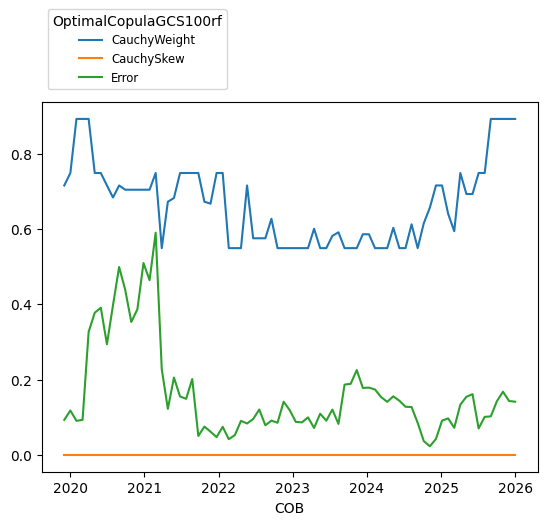

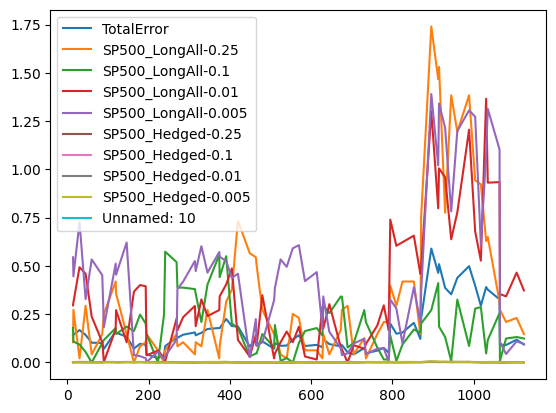

In [1]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize, forest_minimize

run_name = "OptimalCopulaGCS100rf"
cskew = 0.0
prev_x = [0.0]
relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = r'C:\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)
print(dict_avg_var)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []


for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], cskew])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = forest_minimize(error_func, [(0.0, 1.0)], n_calls=15, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(cskew)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()